<a href="https://colab.research.google.com/github/Nyauntu/Data-science-practice/blob/main/T12_ClassSimilarities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Class Similarities Data

First we will import some modules that we might need 😉

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier


##Part 1: Exploring the Data

Now lets read in the data from the ClassSimilarities_2025Spring.csv matrix. [Click here to download the data](https://drive.google.com/uc?download&id=1KHm51Dv09t9bcSaJbSn8eCBLY8ZUsdj2)

In [2]:
# read in data
sims = pd.read_csv('Similarities_2026Spring.csv')
sims.head()

,Timestamp,Which section are you in?,What School are you in?,What is your NYU ID (the one that starts with your initials - used in your email - NOT the N-number),What is your name?,Broccoli,Taylor Swift,Mixed Martial Arts / UFC,Country Music,Camping,...,Broadway Musicals,Scary Roller Coasters,Art Museums,Tattoos,Horror Movies,Superhero Movies / MCU,Pineapple on Pizza,Spicy Food,Mornings,Rank yourself on a scale of Introvert (1) to Extrovert (10)\n
0,2026/04/04 10:58:06 AM AST,Section 2 (MW 11am),Stern,sy3655,Emma Yu,2,3,1,5,2,...,1,3,1,1,5,1,1,3,3,4
1,2026/04/04 12:44:01 PM AST,Section 2 (MW 11am),Stern,jl13844,Jin Lee,3,3,3,3,4,...,4,2,4,3,3,4,3,5,3,6
2,2026/04/04 7:11:24 PM AST,Section 2 (MW 11am),Stern,vnn5704,Vihaan Narvekar,2,3,2,2,2,...,4,1,2,1,2,4,2,4,5,7
3,2026/04/05 2:48:40 AM AST,Section 1 (MW 930am),Shanghai,jz6553,Jiaqi Zhu,5,2,3,4,4,...,4,5,5,1,4,3,2,5,3,2
4,2026/04/05 1:24:51 PM AST,Section 1 (MW 930am),Stern,sc9682,Siya,5,1,3,2,4,...,2,4,1,5,1,5,1,5,5,8


Lets modify the column names for readability:

In [3]:
# change column names
sims.columns = ['Timestamp','Section', 'School','NYUID','Name','Broccoli','TaylorSwift',
                'MMA-UFC','CountryMusic','Camping','Baseball','Winter', 'Golf', 'Jazz',
                'Sushi', 'ReadingNovels', 'Alcohol','Jogging', 'Cannabis', 'Coding',
                'Gym', 'PeanutButter', 'JoeRogan','RomanceReality', 'VideoGames',
                'VeganFood', 'KPop', 'Broadway', 'RollerCoasters',
                'ArtMuseums', 'Tattoos', 'HorrorMovies', 'SuperheroMovies',
                'PineapplePizza', 'SpicyFood', 'Mornings','Extrovert']

In [4]:

sims.set_index('NYUID', inplace=True)

In [5]:
sims.head()

,Timestamp,Section,School,Name,Broccoli,TaylorSwift,MMA-UFC,CountryMusic,Camping,Baseball,...,Broadway,RollerCoasters,ArtMuseums,Tattoos,HorrorMovies,SuperheroMovies,PineapplePizza,SpicyFood,Mornings,Extrovert
NYUID,,,,,,,,,,,,,,,,,,,,,
sy3655,2026/04/04 10:58:06 AM AST,Section 2 (MW 11am),Stern,Emma Yu,2,3,1,5,2,1,...,1,3,1,1,5,1,1,3,3,4
jl13844,2026/04/04 12:44:01 PM AST,Section 2 (MW 11am),Stern,Jin Lee,3,3,3,3,4,4,...,4,2,4,3,3,4,3,5,3,6
vnn5704,2026/04/04 7:11:24 PM AST,Section 2 (MW 11am),Stern,Vihaan Narvekar,2,3,2,2,2,3,...,4,1,2,1,2,4,2,4,5,7
jz6553,2026/04/05 2:48:40 AM AST,Section 1 (MW 930am),Shanghai,Jiaqi Zhu,5,2,3,4,4,2,...,4,5,5,1,4,3,2,5,3,2
sc9682,2026/04/05 1:24:51 PM AST,Section 1 (MW 930am),Stern,Siya,5,1,3,2,4,2,...,2,4,1,5,1,5,1,5,5,8


In [6]:
# frequency table of values for Section
sims['Section'].value_counts()


,count
Section,
Section 2 (MW 11am),23
Section 1 (MW 930am),18


Uncomment the line for your class and create the `class_df` data frame

Call your matrix "class_df"

In [7]:
#class_df = sims[sims['Section'] == 'Section 1 (MW 930am)']
class_df = sims[sims['Section'] == 'Section 2 (MW 11am)']


class_df.shape

(23, 36)

First, lets explore the features of interest.  
Sort by the mean to see which ones are most (and least) popular.
Plot barplots to visualize the distributions of each of the features.
(remove columns that arent of interest)

In [8]:
feature_cols=class_df.columns.drop(['Timestamp','School','Section','Name','Extrovert'])

# plot barplots

plt.figure(figsize=(15, 10))

mean_scores = class_df[feature_cols].mean().sort_values(ascending=False)
mean_scores.round(2)


,0
Sushi,4.35
Gym,4.04
SpicyFood,3.96
ReadingNovels,3.83
SuperheroMovies,3.65
Mornings,3.65
ArtMuseums,3.57
VideoGames,3.52
RollerCoasters,3.48
Coding,3.48


<Figure size 1500x1000 with 0 Axes>

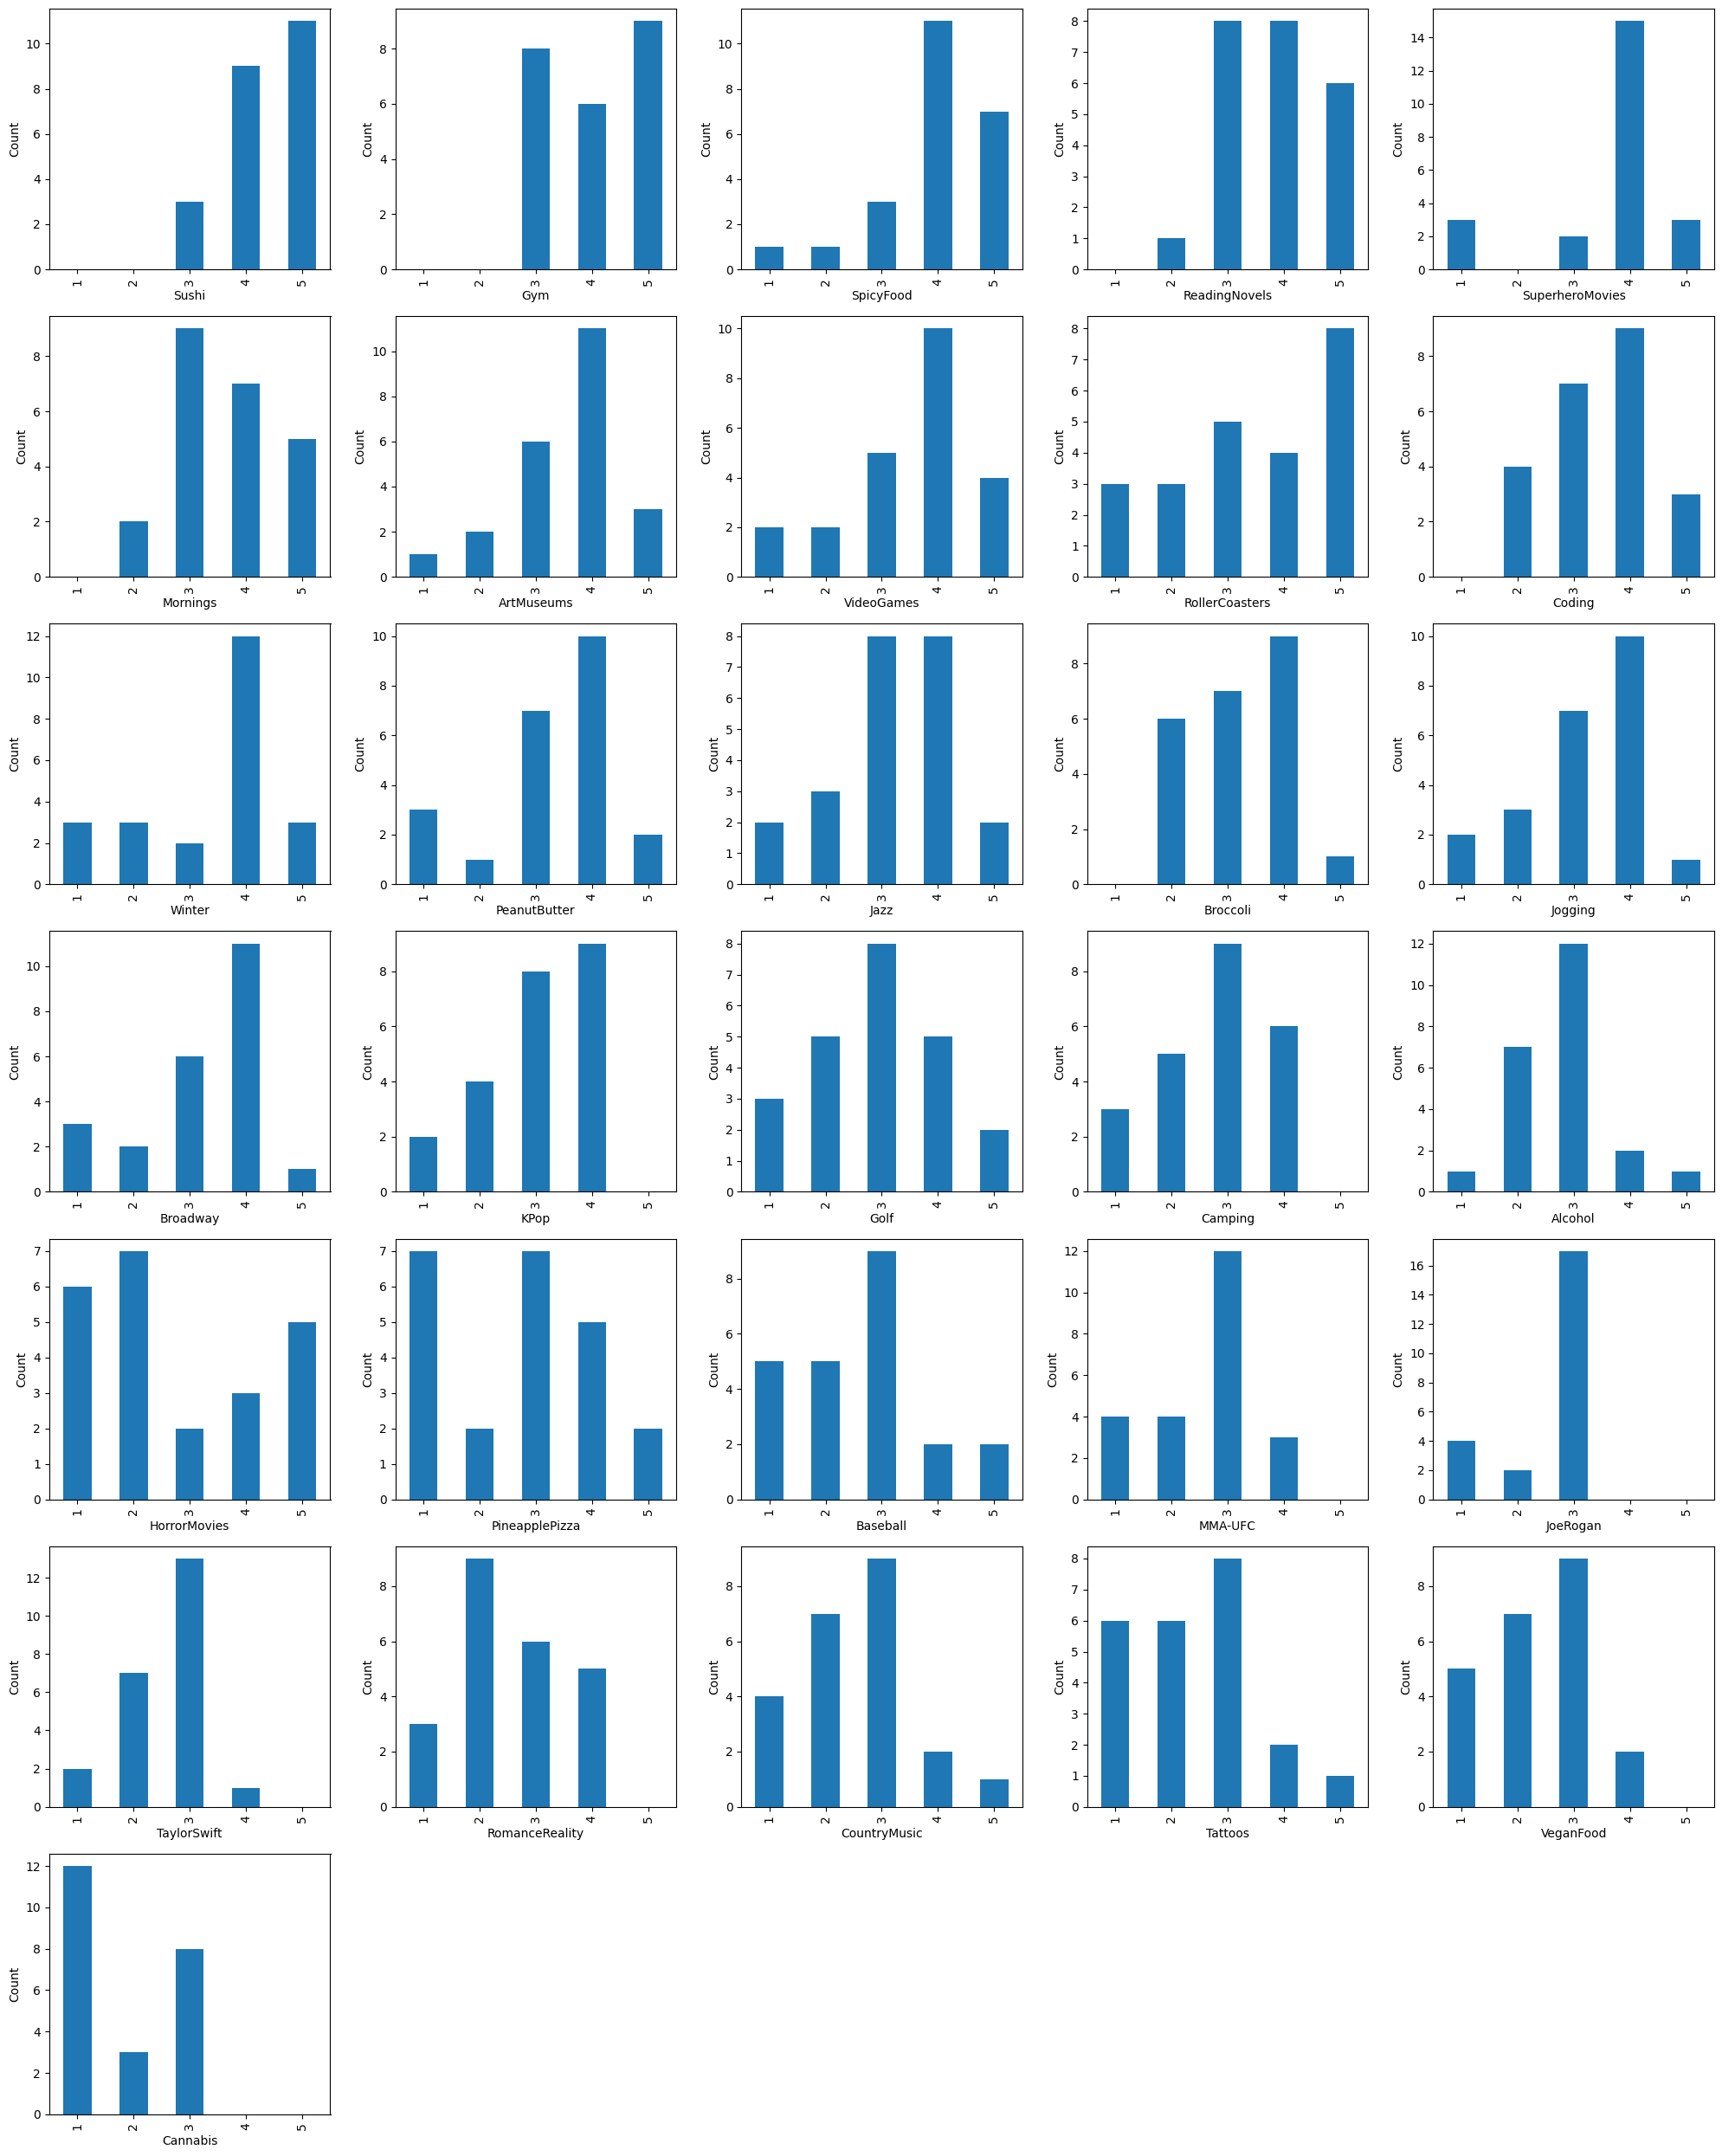

In [9]:
sorted_features = mean_scores.sort_values(ascending=False).index

plt.figure(figsize=(20, 25))
# Iterate over each feature
for i, feature in enumerate(sorted_features):
    # Create a subplot for each feature
    ax = plt.subplot(7, 5, i+1)

    # Reindex the value counts to include all values 1 through 5
    counts = class_df[feature].value_counts().reindex(range(1, 6), fill_value=0)

    # Plot the bar chart
    counts.plot(kind='bar', ax=ax)

    # Set the x-axis range
    plt.xticks(range(0, 5))

    # Set the title and labels
    ax.set_ylabel('Count')

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

Plot a heatmap of the correlations to see which features are most positively and negatively correlated.  Use the `.corr()` function in seaborn and `sns.heatmap`.  Any interesting results here?


*you can play with colorbrewer colors here!  My favorite is cmap='RdBu_r' and dont forget to set the limits to (-1,1) using `vmax` and `vmin`*

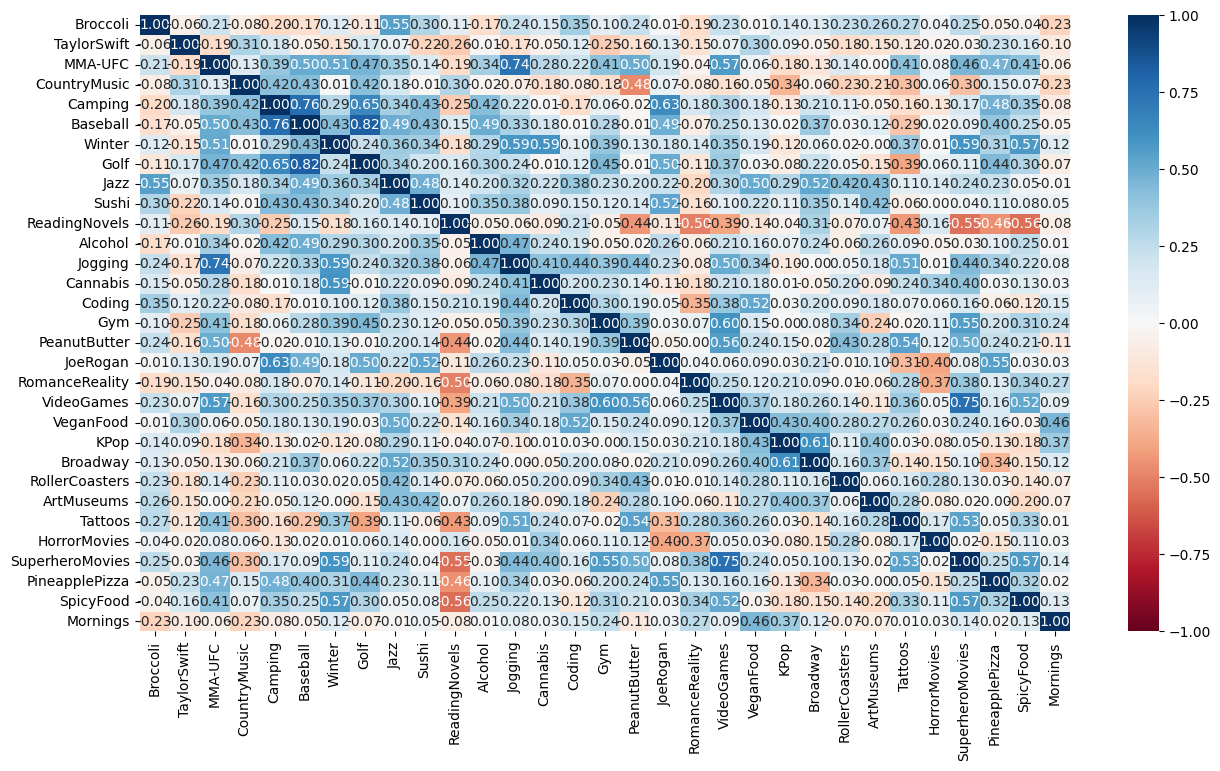

In [10]:
# heatmap of correlations

import seaborn as sns

# Calculate the correlation matrix
corr = class_df[feature_cols].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True,fmt=".2f", cmap='RdBu', cbar=True,vmin=-1,vmax=1)

plt.show()

Now plot a histogram of Extroversion.

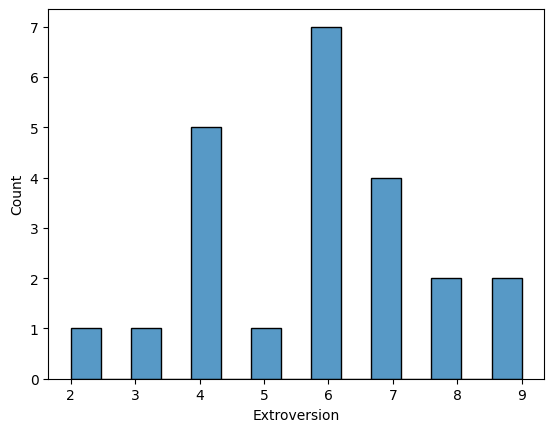

In [11]:
# make histogram of Extroversion

sns.histplot(class_df['Extrovert'],bins=15)
plt.xlabel('Extroversion')
plt.show()


## Part 2: Distances between students


One helpful suggestions would be to set *NYUID* as the index so that you can easily extract the data for any given  NYUID.

In [ ]:
class_df.columns

Use `sklearn.pairwise_distances`  to calculate a distance matrix "dist_matrix" (It may be helpful to convert the dist_matrix into a data frame using pd.DataFrame)

Use Manhattan distance because it will be more iterpretable.

Identify your data with your NYUID and see if you can find the three most similar students to you and the three least similar students to you

In [12]:
from sklearn.metrics import pairwise_distances

# Calculate the pairwise distances
dist_matrix = pairwise_distances(class_df[feature_cols].values, metric='manhattan')

# Convert the distance matrix into a DataFrame
dist_df = pd.DataFrame(dist_matrix, index=class_df.index, columns=class_df.index)

dist_df


NYUID,sy3655,jl13844,vnn5704,km6238,jgs9241,sb9378,kz2818,Jwn7470,cav9233,sl9820,...,eyc6934,AL7685,azw7237,cr3488,mit2470,tab9225,my2474,yc7458,zy2859,zx1793
NYUID,,,,,,,,,,,,,,,,,,,,,
sy3655,0.0,59.0,52.0,62.0,42.0,49.0,51.0,52.0,38.0,64.0,...,55.0,48.0,55.0,59.0,61.0,59.0,60.0,47.0,58.0,55.0
jl13844,59.0,0.0,33.0,33.0,49.0,28.0,22.0,29.0,43.0,29.0,...,26.0,29.0,24.0,36.0,26.0,26.0,29.0,30.0,27.0,12.0
vnn5704,52.0,33.0,0.0,34.0,50.0,27.0,35.0,32.0,42.0,36.0,...,31.0,38.0,25.0,39.0,35.0,35.0,28.0,33.0,32.0,31.0
km6238,62.0,33.0,34.0,0.0,52.0,33.0,35.0,36.0,56.0,36.0,...,29.0,42.0,31.0,27.0,31.0,31.0,36.0,27.0,42.0,35.0
jgs9241,42.0,49.0,50.0,52.0,0.0,43.0,39.0,44.0,36.0,50.0,...,45.0,48.0,45.0,41.0,43.0,49.0,44.0,31.0,42.0,45.0
sb9378,49.0,28.0,27.0,33.0,43.0,0.0,28.0,29.0,39.0,27.0,...,22.0,35.0,24.0,32.0,30.0,30.0,29.0,24.0,25.0,20.0
kz2818,51.0,22.0,35.0,35.0,39.0,28.0,0.0,21.0,39.0,27.0,...,24.0,31.0,26.0,38.0,30.0,30.0,23.0,28.0,25.0,18.0
Jwn7470,52.0,29.0,32.0,36.0,44.0,29.0,21.0,0.0,42.0,32.0,...,31.0,36.0,27.0,45.0,29.0,29.0,26.0,35.0,28.0,25.0
cav9233,38.0,43.0,42.0,56.0,36.0,39.0,39.0,42.0,0.0,44.0,...,43.0,36.0,45.0,35.0,43.0,55.0,46.0,43.0,36.0,37.0


Find the three most similar students to you and the three least similar students to you.

Remember that the most similar student will be the student themself!  (distance = 0) so you will have to account for that.

also you might want to check to make sure that the input_NYUID is actuall in the index or else you will get an error.

In [21]:
input_NYUID = 'yc7458'

# Get the distances for the input NYUID
distances = dist_df.loc[input_NYUID]

# Get the 3 most similar students (excluding the input student itself)
most_similar = distances.nsmallest(4).iloc[1:] #starting at index 1 removes the student themself as the most similar

# Get the 3 least similar students
least_similar = distances.nlargest(3)

# Print the NYUID and Name of the most and least similar students
print("Most similar students to :", input_NYUID, class_df.loc[input_NYUID, 'Name'])
for NYUID in most_similar.index:
    print(NYUID, class_df.loc[NYUID, 'Name'],most_similar[NYUID])

print("\nLeast similar students to :", input_NYUID, class_df.loc[input_NYUID, 'Name'])
for NYUID in least_similar.index:
    print(NYUID, class_df.loc[NYUID, 'Name'],least_similar[NYUID])


Most similar students to : yc7458 Yi Cui
sb9378 Siddhant Bhatnagar 24.0
eyc6934 Eric Chen 26.0
km6238 Kushal Mamillapalli 27.0

Least similar students to : yc7458 Yi Cui
sy3655 Emma Yu 47.0
cav9233 Camila Vazquez 43.0
ksm6057 Kabhir Mongia 43.0


Which two people are the closest? Because we use Manhattan distance, this distance is interpreted as the total sum of the absolute differences of the 24 features.

You can look for the smallest value (smallest distance) in the matrix, but be careful to account for the fact that the diagonals are zero...


In [22]:
# Replace the diagonal of the distance matrix with np.inf
np.fill_diagonal(dist_df.values, np.inf)

# Find the NYUIDs of the two students who are the closest
min_dist = np.unravel_index(np.argmin(dist_df.values), dist_df.shape)
mdl=list(min_dist)
cls=dist_df.index[mdl]

print( class_df.loc[cls[0], 'Name'], ":", class_df.loc[cls[1], 'Name'], dist_df.loc[cls[0], cls[1]])



Jin Lee : Zheyi 12.0


Which two students are the furthest apart?

In [23]:
# Replace the diagonal of the distance matrix with 0
np.fill_diagonal(dist_df.values, 0)

# Find the NYUIDs of the two students who are the closest
max_dist = np.unravel_index(np.argmax(dist_df.values), dist_df.shape)
mdl=list(max_dist)
cls=dist_df.index[mdl]

print( class_df.loc[cls[0], 'Name'], ":", class_df.loc[cls[1], 'Name'], dist_df.loc[cls[0], cls[1]])

Emma Yu : Steven Lo Cen 64.0


## Part 3: Clustering

Lets perform hierarchical clustering to find the "6-cluster solution" and print out the clusters.

Did any of you end up in clusters with your project team members?

All code provided...



In [24]:
from sklearn.cluster import AgglomerativeClustering

# Create an AgglomerativeClustering model with 4 clusters
cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Fit the model to the data and predict the cluster labels
cluster_labels = cluster.fit_predict(class_df[feature_cols])
student_clusters = class_df.assign(Cluster=cluster_labels)



In [26]:
for cluster, data in student_clusters.groupby('Cluster'):
    print(f"Cluster {cluster}:")
    print(data.Name.tolist())
    print()

Cluster 0:
['Jonah Schachter', 'Camila Vazquez', 'Alicia Li']

Cluster 1:
['Jin Lee', 'Vihaan Narvekar', 'Nina Zhou', 'Jacob Ng', 'Steven Lo Cen', 'Kyle Park', 'Kabhir Mongia', 'Eric Chen', 'Alex Wang ', 'Mathis TOURE', 'Trace Binder', 'Mia', 'Icey Yuan', 'Zheyi']

Cluster 2:
['Kushal Mamillapalli', 'Siddhant Bhatnagar', 'Nisha Kurup', 'Chelsea Rosas Zavala', 'Yi Cui']

Cluster 3:
['Emma Yu']



Plot the dendrogram.

Play around with the following  parameters:
in the linkage function : `method` and `metric`

in the dendrogram: `orientation` - for the direction of the plot
                : `color_threshold` - for how the plot is colored showing different clusters

can use `labels=class_df.index` to show NYUID instead of names...


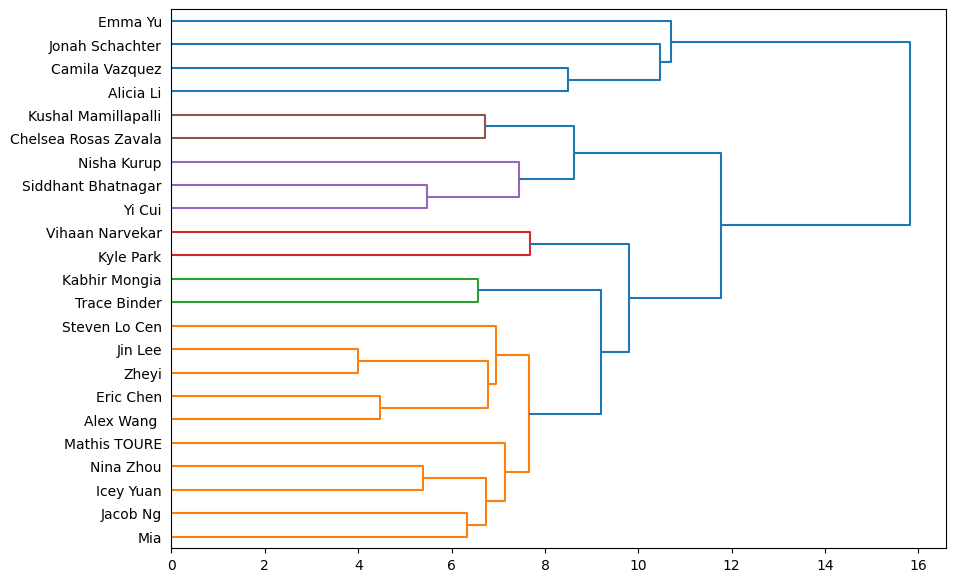

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Create a linkage matrix
linked = linkage(class_df[feature_cols], 'ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='right', color_threshold=8, labels=class_df.Name.tolist(), distance_sort='descending', show_leaf_counts=True)
plt.show()

For fun - we can also cluster the *features* to see which are most similar...by passing the feature correlation matrix into the `linked` function




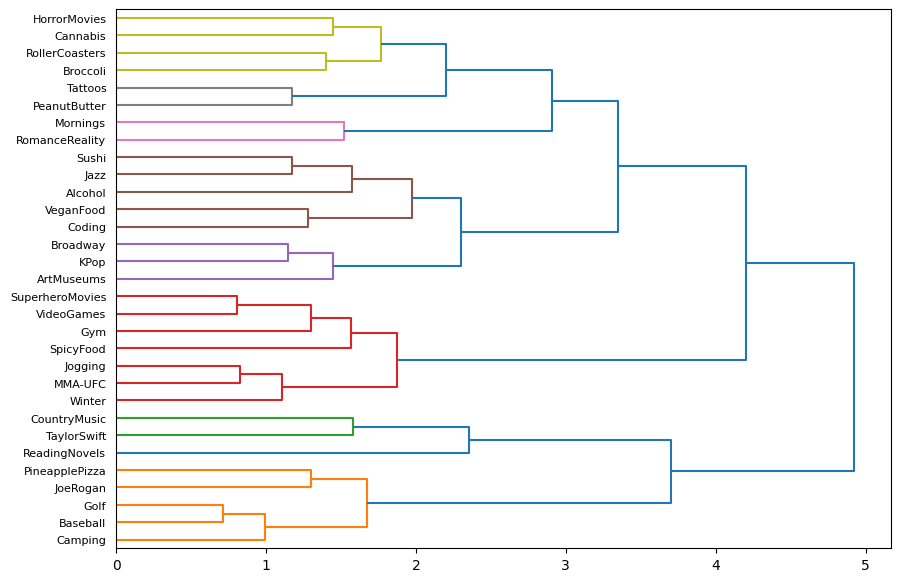

In [27]:
# Calculate the correlation matrix
corr = class_df[feature_cols].corr()

# Create a linkage matrix based on the correlation matrix
linked = linkage(corr, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=corr.columns, orientation='right',color_threshold = 2)
plt.show()

### Heatmap of Feature Averages per Cluster (Clustermap)

This heatmap visualizes the average score for each feature within each identified cluster. It helps to understand the distinguishing characteristics and preferences of students in different clusters. Higher values (darker color, depending on cmap) indicate a stronger average preference for that feature within the cluster.

<Figure size 1200x800 with 0 Axes>

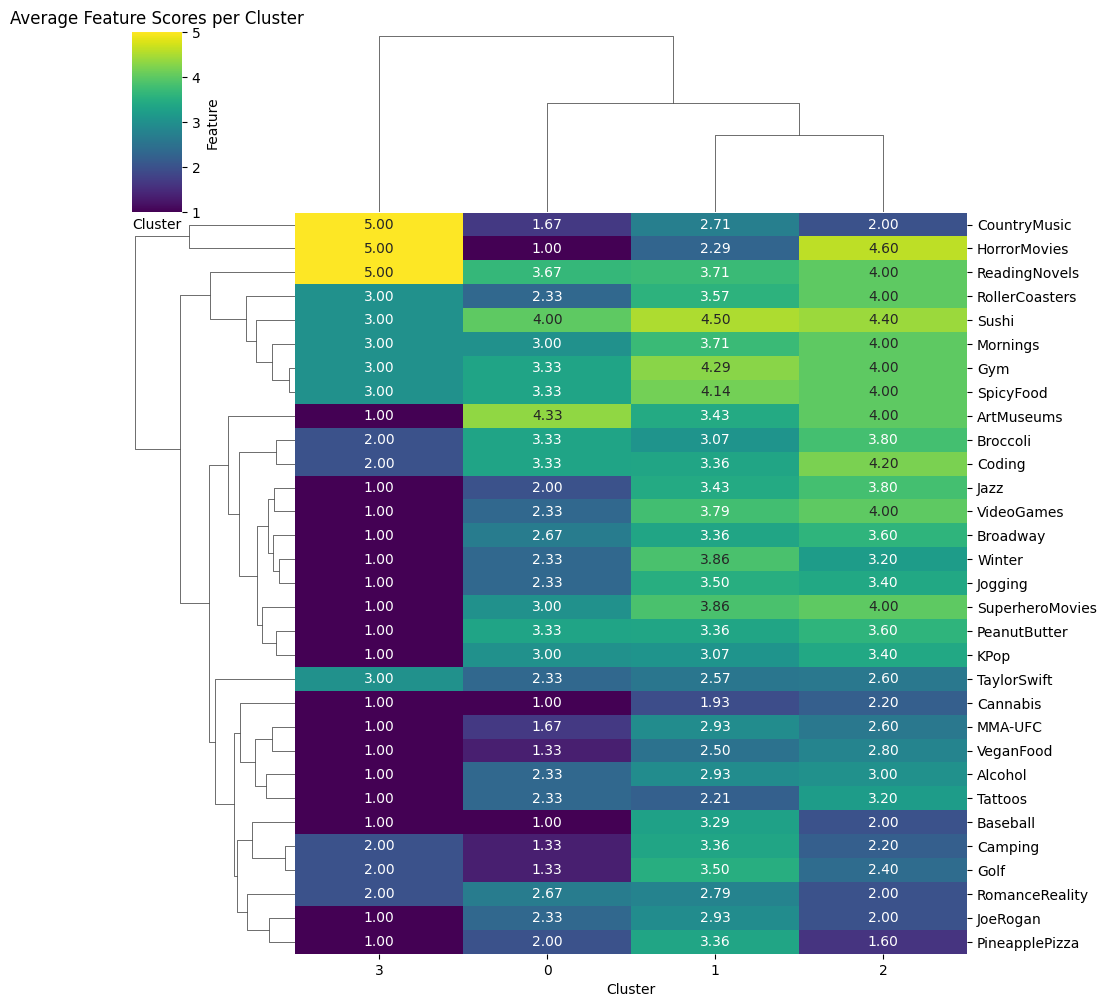

In [28]:
# Calculate the mean of each feature for each cluster
cluster_feature_means = student_clusters.groupby('Cluster')[feature_cols].mean()

# Create a heatmap of these means
plt.figure(figsize=(12, 8))
sns.clustermap(cluster_feature_means.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Average Feature Scores per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.show()


##Part 4: K nearest neighbors for predicting targets##

We want to know if the preferences data has value in predicting Extroversion.

Since we dont have a lot of data in each class, use the entire `sims` data (both classes) and split into 80/20 and fit a knn with k=5 (aka `KNeighborsRegressor(n_neighbors=5)`


In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# Select the features and target
target = 'Extrovert'

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(sims[feature_cols], sims[target], test_size=0.2, random_state=13)

# Create a KNeighborsRegressor with k=5
knn = KNeighborsRegressor(n_neighbors=3)

# Fit the model to the training data
knn.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=3)

Make a scatterplot of predicted values for the test set on the x-axis and actual values on the y-axis.

Does the prediction seem any good?

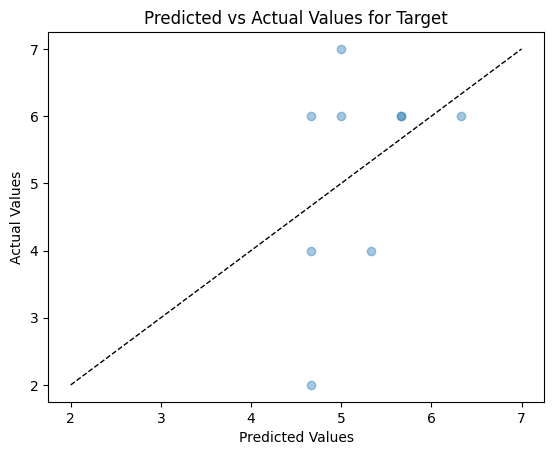

In [30]:

import matplotlib.pyplot as plt

# Make predictions on the testing data
y_pred = knn.predict(X_test)

# Create a scatter plot of the actual values versus the predicted values
plt.scatter(y_pred,y_test,alpha=0.4)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Predicted vs Actual Values for Target')

# Add a reference line
plt.plot([y_test.min() , y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)

plt.show()

Using a for-loop - find the best k via RMSE.

(Optional - compare to a dumb model that uses just the average of the training set)

In [31]:
from sklearn.metrics import root_mean_squared_error
#yikes this is not good!  But lets calcuate the best k anyway

rmse_best = np.inf
for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    if (rmse < rmse_best):
      rmse_best = rmse
      best_k = k
    print('k=', k, 'RMSE:', round(rmse,3))
print("\nBest value of k: ", best_k," with RMSE= ",rmse_best)

k= 1 RMSE: 1.374
k= 2 RMSE: 1.384
k= 3 RMSE: 1.352
k= 4 RMSE: 1.362
k= 5 RMSE: 1.538
k= 6 RMSE: 1.477
k= 7 RMSE: 1.584
k= 8 RMSE: 1.62
k= 9 RMSE: 1.63
k= 10 RMSE: 1.522
k= 11 RMSE: 1.525
k= 12 RMSE: 1.558
k= 13 RMSE: 1.656
k= 14 RMSE: 1.678
k= 15 RMSE: 1.675
k= 16 RMSE: 1.714
k= 17 RMSE: 1.665
k= 18 RMSE: 1.698
k= 19 RMSE: 1.707
k= 20 RMSE: 1.669

Best value of k:  3  with RMSE=  1.3517250067329376


In [32]:
# dumb_model - predict everyone with the mean of the population

# RMSE of using just the mean to predict
rmse_dumb = np.sqrt(((y_test - y_train.mean())**2).mean())
rmse_model = root_mean_squared_error(y_test, y_pred)


print(f"RMSE(dumb) = {round(rmse_dumb,2)} and RMSE(model) = {round(rmse_best,2)}")


RMSE(dumb) = 1.78 and RMSE(model) = 1.35
